In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

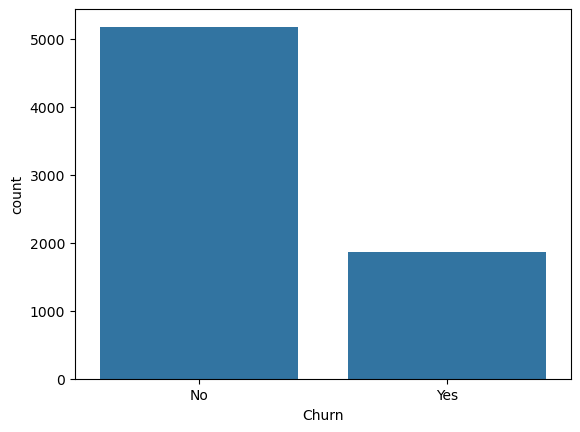

In [11]:
sns.countplot(x='Churn',data=df)

In [12]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.drop('customerID',axis=1,inplace=True)

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [16]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [18]:
df.rename(columns={'gender':'Gender'},inplace=True)                                                

In [19]:
df.head()

,Gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [20]:
df['Partner']=df['Partner'].map({'Yes':1,'No':0})
df['Dependents']=df['Dependents'].map({'No':0,'Yes':1})
df['PhoneService']=df['PhoneService'].map({'No':0,'Yes':1})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes':1,'No':0})
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes':1,'No':0})
df['DeviceProtection']=df['DeviceProtection'].map({'Yesy':1,'No':0})
df['TechSupport']=df['TechSupport'].map({'Yes':1,'No':0})
df['StreamingTV']=df['StreamingTV'].map({'Yes':1,'No':0})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0})
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1,'No':0})
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df['MultipleLines']=df['MultipleLines'].map({'No':0,'Yes':1,"No phone service":2})
df['InternetService']=df['InternetService'].map({'Fiber optic':2,'DSL':1,'No':0})
df['Contract']=df['Contract'].map({'Month-to-month':2,'Two year':1,'One year':0})
df['PaymentMethod']=df['PaymentMethod'].map({'Electronic check':3,'Mailed check':2,'Bank transfer (automatic)':1,'Credit card (automatic)':0})

In [21]:
df['MultipleLines'].value_counts()

MultipleLines
0    3390
1    2971
2     682
Name: count, dtype: int64

In [22]:
df['InternetService'].value_counts()

InternetService
2    3096
1    2421
0    1526
Name: count, dtype: int64

In [23]:
df['Contract'].value_counts()

Contract
2    3875
1    1695
0    1473
Name: count, dtype: int64

In [24]:
df['PaymentMethod'].value_counts()

PaymentMethod
3    2365
2    1612
1    1544
0    1522
Name: count, dtype: int64

In [25]:
df.head()

,Gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,2,1,0.0,1.0,0.0,0.0,0.0,0.0,2,1,3,29.85,29.85,0
1,1,0,0,0,34,1,0,1,1.0,0.0,NaN,0.0,0.0,0.0,0,0,2,56.95,1889.50,0
2,1,0,0,0,2,1,0,1,1.0,1.0,0.0,0.0,0.0,0.0,2,1,2,53.85,108.15,1
3,1,0,0,0,45,0,2,1,1.0,0.0,NaN,1.0,0.0,0.0,0,0,1,42.30,1840.75,0
4,0,0,0,0,2,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,2,1,3,70.70,151.65,1


In [26]:
x=df.drop('Churn',axis=1)
y=df['Churn']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [27]:
model = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [28]:
print(model.feature_importances_)

[0.         0.00738034 0.         0.         0.19200585 0.01397182
 0.01573734 0.13916132 0.02114024 0.         0.         0.
 0.         0.00495155 0.52312186 0.         0.01803557 0.03060369
 0.03389042]


In [29]:
print("Confusion Matrix : \n",confusion_matrix(y_test,y_pred))

Confusion Matrix : 
 [[900 136]
 [142 231]]


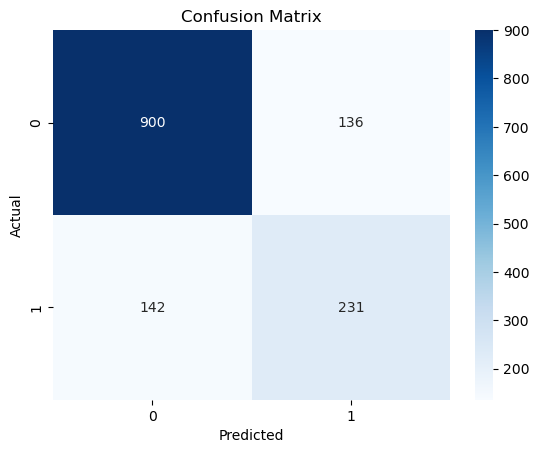

In [30]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
print("Accuray score : ",accuracy_score(y_test,y_pred))
print("F1_score : ",f1_score(y_test,y_pred))

Accuray score :  0.8026969481902059
F1_score :  0.6243243243243243


In [32]:
print("Classification Report : ",classification_report(y_test,y_pred))

Classification Report :                precision    recall  f1-score   support

           0       0.86      0.87      0.87      1036
           1       0.63      0.62      0.62       373

    accuracy                           0.80      1409
   macro avg       0.75      0.74      0.75      1409
weighted avg       0.80      0.80      0.80      1409



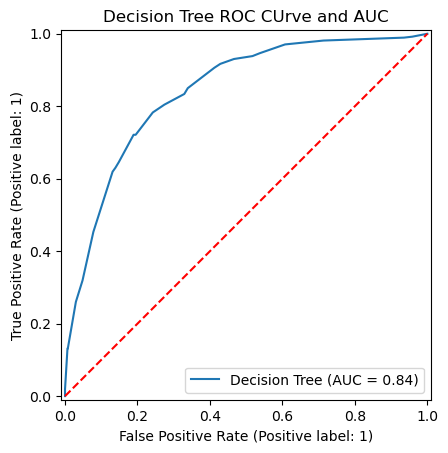

In [33]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,x_test,y_test,name='Decision Tree')
plt.title("Decision Tree ROC CUrve and AUC")
plt.plot([0,1],[0,1],'r--')
plt.show()

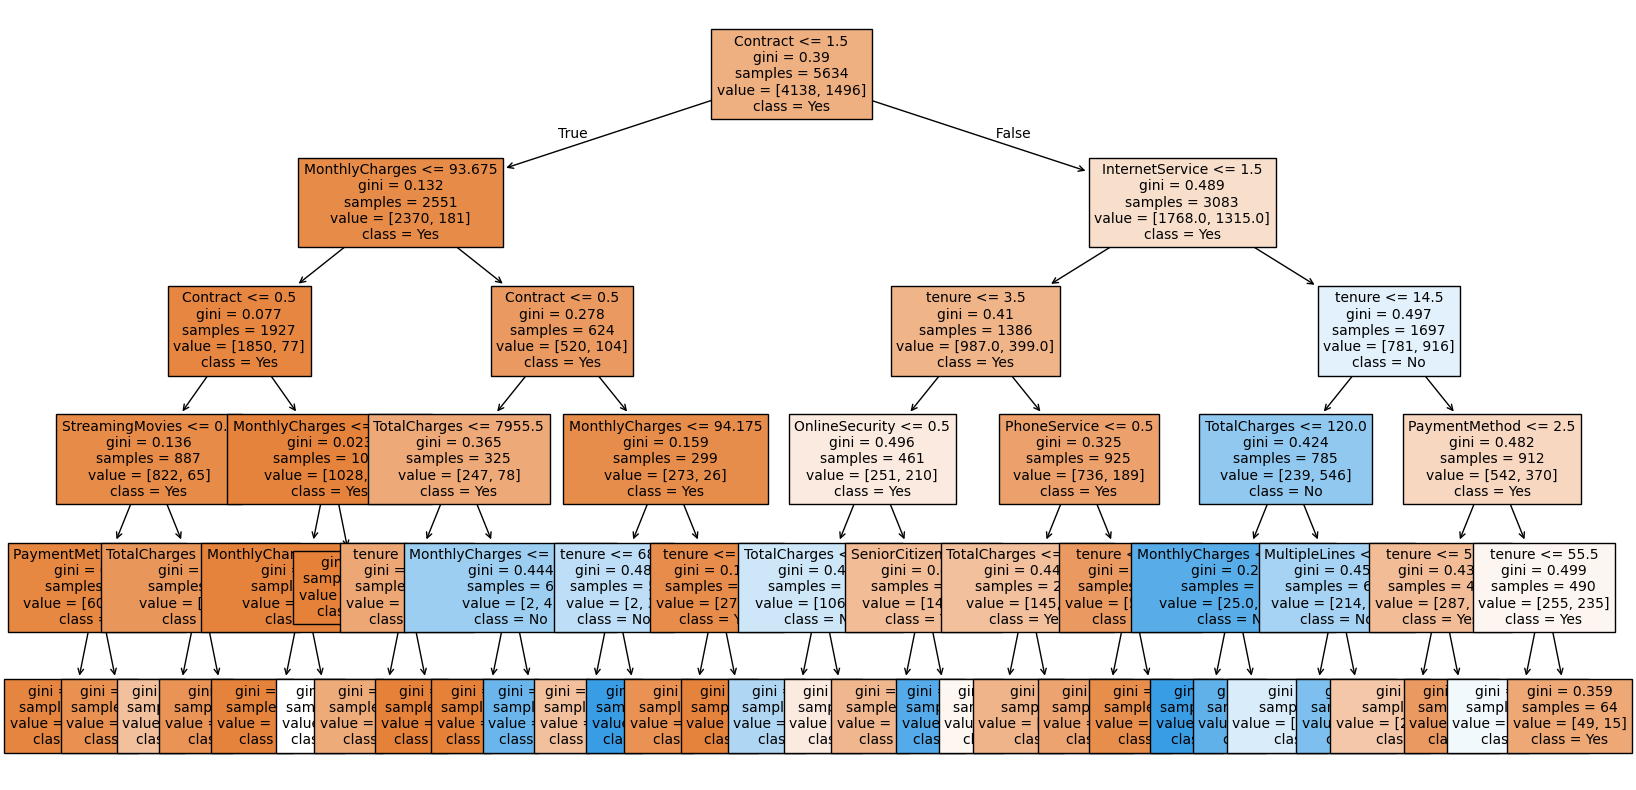

In [34]:
plt.figure(figsize=(20,10))
tree.plot_tree(model,feature_names=x.columns,class_names=['Yes','No'],filled=True,fontsize=10)
plt.savefig('decision_tree.png',dpi=150)
plt.show()

In [35]:
from sklearn.model_selection import GridSearchCV

parameters = {'criterion':['gini','entropy'],
              'max_depth':[3,5,7,10],
              'min_samples_split':[2,5,10],
              'min_samples_leaf':[1,2,4]}

grid_search = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid_search.fit(x_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [46]:
print("Best Parameters : ",grid_search.best_params_)

Best Parameters :  {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [47]:
model2=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_leaf=2,min_samples_split=2)
model2.fit(x_train,y_train)

y_pred_test = model2.predict(x_test)

In [43]:
print("Accuray score : ",accuracy_score(y_test,y_pred_test))
print("F1_score : ",f1_score(y_test,y_pred_test))

Accuray score :  0.8034066713981547
F1_score :  0.625169147496617


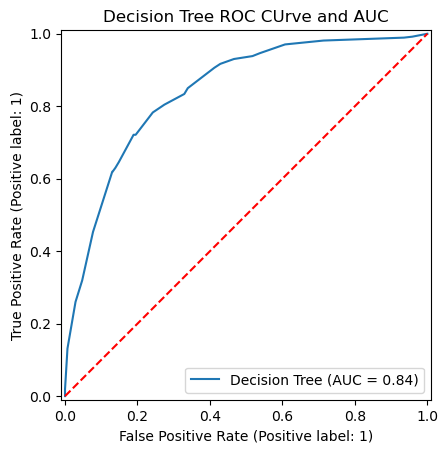

In [44]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model2,x_test,y_test,name='Decision Tree')
plt.title("Decision Tree ROC CUrve and AUC")
plt.plot([0,1],[0,1],'r--')
plt.show()

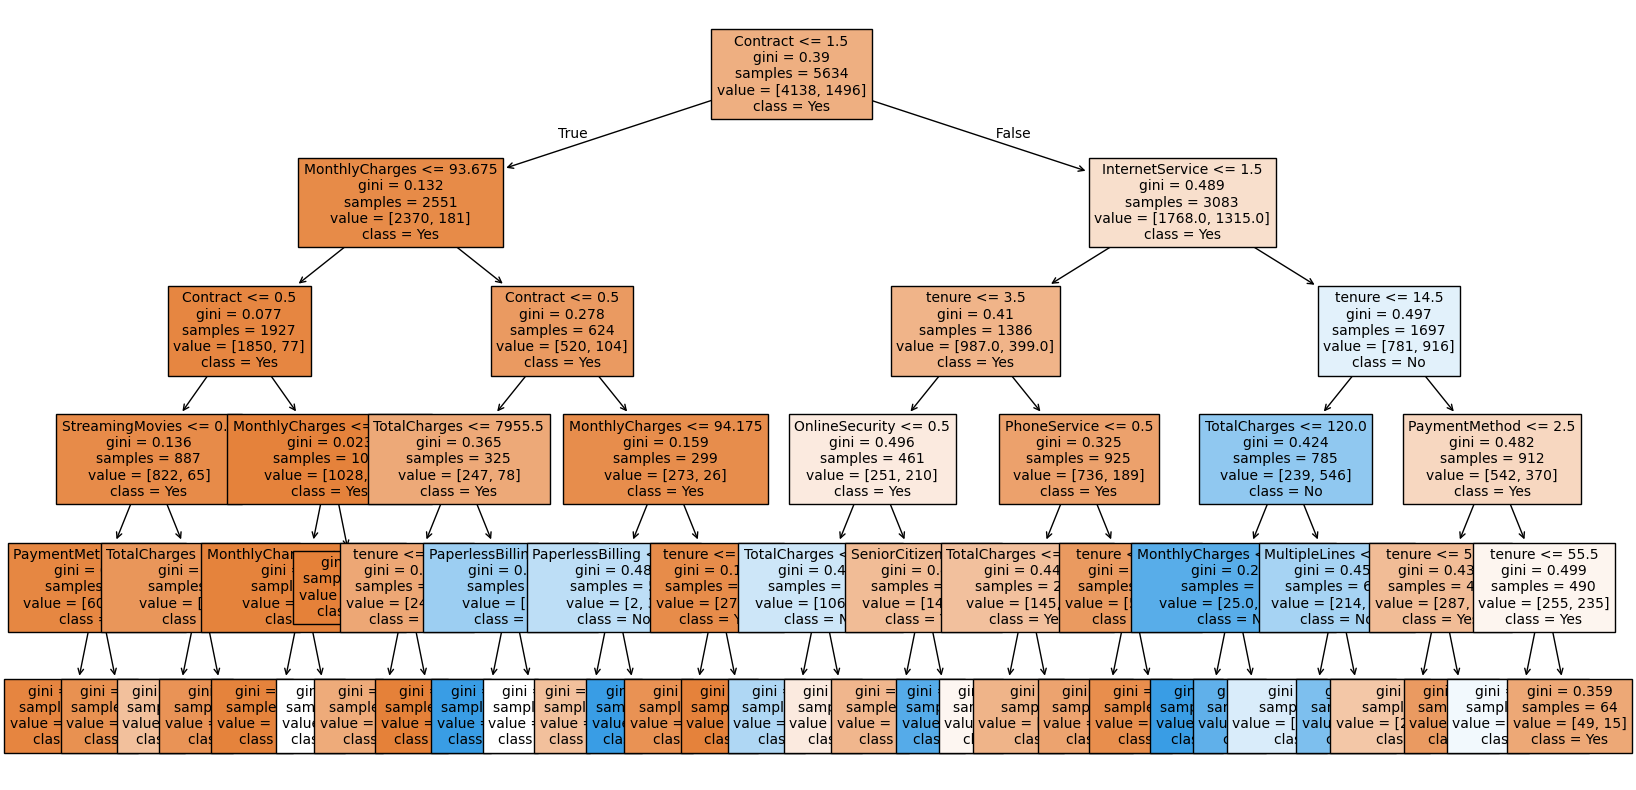

In [45]:
plt.figure(figsize=(20,10))
tree.plot_tree(model2,feature_names=x.columns,class_names=['Yes','No'],filled=True,fontsize=10)
plt.savefig('decision_tree.png',dpi=150)
plt.show()